In [ ]:
import numpy as np
import pickle
import torch
import os, sys
helpers_path = os.path.join('/ether/aegis/Research_HEP/NRAD/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier

In [ ]:
# Import MC samples
scaler_path = "/ether/aegis/Research_HEP/NRAD/SemiVisJets/mc_scalers"
mc_path = "/ether/aegis/Research_HEP/NRAD/SemiVisJets/data"
# signal_path = "/ether/aegis/Research_HEP/NRAD/Signal/processed_signal"
signal_path = "/ether/aegis/Research_HEP/NRAD/Signal/lxplus_signal"
# signal_path = "/ether/aegis/Research_HEP/NRAD/Signal/processed_signal_MII"

var_names = ["ht", "met", "m_jj", "tau21_j1", "tau21_j2", "tau32_j1", "tau32_j2"]

# Load MC samples

mc_events = np.load(f"{mc_path}/mc_events_chunk03.npz", allow_pickle=True)

with open(f"{scaler_path}/mc_scaler_chunk03.pkl","rb") as f:
    mc_scaler = pickle.load(f)

print(mc_events["mc_events_sr"].shape)


signal_samples = {}
signal_modes = ["1000_2", "1000_4", "1000_6", "1000_8", "2000_2", "2000_4", "2000_6", "2000_8", "3000_2", "3000_4", "3000_6", "3000_8"]

# Import signal samples
all_columns = [
    "pT_j1", "eta_j1", "phi_j1",
    "pT_j2", "eta_j2", "phi_j2",
    "m_jj", "tau21_j1", "tau21_j2",
    "tau32_j1", "tau32_j2",
    "met", "phi_met", "min_dPhi", "ht"
]

# Find indices of desired variables
cols_to_use = [all_columns.index(v) for v in var_names]

def sr_mask(events):
    ht = events[:,0]
    met = events[:,1]
    # Apply SR cuts
    mask = (ht > 600) & (met > 600)
    return mask

for mode in signal_modes:
    signal_data = np.loadtxt(f"{signal_path}/{mode}_events.txt", skiprows=1, usecols=cols_to_use)
    sig_mask = sr_mask(signal_data)
    signal_samples[mode] = mc_scaler.transform(signal_data[sig_mask])
    print(f"Loaded signal mode {mode} with shape: {signal_data.shape}")
    print(f"After SR cuts, shape: {signal_samples[mode].shape}")

(46968, 7)
Loaded signal mode 1000_2 with shape: (911, 7)
After SR cuts, shape: (117, 7)
Loaded signal mode 1000_4 with shape: (805, 7)
After SR cuts, shape: (172, 7)
Loaded signal mode 1000_6 with shape: (707, 7)
After SR cuts, shape: (222, 7)
Loaded signal mode 1000_8 with shape: (611, 7)
After SR cuts, shape: (264, 7)
Loaded signal mode 2000_2 with shape: (3982, 7)
After SR cuts, shape: (1649, 7)
Loaded signal mode 2000_4 with shape: (4407, 7)
After SR cuts, shape: (2792, 7)
Loaded signal mode 2000_6 with shape: (4536, 7)
After SR cuts, shape: (3556, 7)
Loaded signal mode 2000_8 with shape: (4507, 7)
After SR cuts, shape: (3939, 7)
Loaded signal mode 3000_2 with shape: (1810, 7)
After SR cuts, shape: (1105, 7)
Loaded signal mode 3000_4 with shape: (2191, 7)
After SR cuts, shape: (1751, 7)
Loaded signal mode 3000_6 with shape: (2450, 7)
After SR cuts, shape: (2202, 7)
Loaded signal mode 3000_8 with shape: (2508, 7)
After SR cuts, shape: (2386, 7)


In [ ]:
mixed_data = {}
for mode in signal_modes:
    mixed_data[mode] = np.vstack((mc_events["mc_events_sr"], signal_samples[mode]))
    print(f"Mixed data for mode {mode} has shape: {mixed_data[mode].shape}")

Mixed data for mode 1000_2 has shape: (47085, 7)
Mixed data for mode 1000_4 has shape: (47140, 7)
Mixed data for mode 1000_6 has shape: (47190, 7)
Mixed data for mode 1000_8 has shape: (47232, 7)
Mixed data for mode 2000_2 has shape: (48617, 7)
Mixed data for mode 2000_4 has shape: (49760, 7)
Mixed data for mode 2000_6 has shape: (50524, 7)
Mixed data for mode 2000_8 has shape: (50907, 7)
Mixed data for mode 3000_2 has shape: (48073, 7)
Mixed data for mode 3000_4 has shape: (48719, 7)
Mixed data for mode 3000_6 has shape: (49170, 7)
Mixed data for mode 3000_8 has shape: (49354, 7)


In [ ]:
x_test = {}
y_test = {}

n_bkg = mc_events["mc_events_sr"].shape[0]

for mode in signal_modes:
    n_sig = signal_samples[mode].shape[0]

    # x_test = mixed features (already scaled)
    x_test[mode] = mixed_data[mode]

    # y_test = 0 for background, 1 for signal
    y_bkg = np.zeros(n_bkg)
    y_sig = np.ones(n_sig)
    y_test[mode] = np.concatenate((y_bkg, y_sig))

    print(f"Mode {mode}: x_test {x_test[mode].shape}, y_test {y_test[mode].shape}, signal fraction = {n_sig / (10*np.sqrt(n_sig + n_bkg*5)):.3f}")


Mode 1000_2: x_test (47085, 7), y_test (47085,), signal fraction = 0.024
Mode 1000_4: x_test (47140, 7), y_test (47140,), signal fraction = 0.035
Mode 1000_6: x_test (47190, 7), y_test (47190,), signal fraction = 0.046
Mode 1000_8: x_test (47232, 7), y_test (47232,), signal fraction = 0.054
Mode 2000_2: x_test (48617, 7), y_test (48617,), signal fraction = 0.339
Mode 2000_4: x_test (49760, 7), y_test (49760,), signal fraction = 0.573
Mode 2000_6: x_test (50524, 7), y_test (50524,), signal fraction = 0.728
Mode 2000_8: x_test (50907, 7), y_test (50907,), signal fraction = 0.806
Mode 3000_2: x_test (48073, 7), y_test (48073,), signal fraction = 0.227
Mode 3000_4: x_test (48719, 7), y_test (48719,), signal fraction = 0.360
Mode 3000_6: x_test (49170, 7), y_test (49170,), signal fraction = 0.452
Mode 3000_8: x_test (49354, 7), y_test (49354,), signal fraction = 0.490


In [ ]:
# Load Trained Machine Learning models

import glob

base_path = "/ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr"

# Datasets
datasets = [f"Data0{i}" for i in range(1, 6)]

# Initialize dicts
generate_models_paths = {}
reweight_models_paths = {}

for d in datasets:
    # Collect .pt files belonging to this dataset
    gen_models = sorted(glob.glob(f"{base_path}/model_generate_SR_{d}_MC*run*.pt"))
    rew_models = sorted(glob.glob(f"{base_path}/model_reweight_SR_{d}_MC*run*.pt"))

    generate_models_paths[d] = gen_models
    reweight_models_paths[d] = rew_models

    print(f"{d}: {len(gen_models)} generate models, {len(rew_models)} reweight models")

# Optional sanity check
# print("\nExample:")
# print("Data01 generate models:", generate_models_paths["Data01"][:3])
# print("Data01 reweight models:", reweight_models_paths["Data01"][:3])

Data01: 20 generate models, 20 reweight models
Data02: 20 generate models, 20 reweight models
Data03: 20 generate models, 20 reweight models
Data04: 20 generate models, 20 reweight models
Data05: 20 generate models, 20 reweight models


In [ ]:
print("mc_events_sr shape:", mc_events["mc_events_sr"].shape)
for mode in signal_modes:
    print(mode, "signal shape:", signal_samples[mode].shape, "mixed:", mixed_data[mode].shape)
    print(" label counts:", np.unique(y_test[mode], return_counts=True))
    print(" first 5 y:", y_test[mode][:10])
    # print(" example features (first row):", x_test[mode][0])

mc_events_sr shape: (46968, 7)
1000_2 signal shape: (117, 7) mixed: (47085, 7)
 label counts: (array([0., 1.]), array([46968,   117]))
 first 5 y: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
1000_4 signal shape: (172, 7) mixed: (47140, 7)
 label counts: (array([0., 1.]), array([46968,   172]))
 first 5 y: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
1000_6 signal shape: (222, 7) mixed: (47190, 7)
 label counts: (array([0., 1.]), array([46968,   222]))
 first 5 y: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
1000_8 signal shape: (264, 7) mixed: (47232, 7)
 label counts: (array([0., 1.]), array([46968,   264]))
 first 5 y: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
2000_2 signal shape: (1649, 7) mixed: (48617, 7)
 label counts: (array([0., 1.]), array([46968,  1649]))
 first 5 y: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
2000_4 signal shape: (2792, 7) mixed: (49760, 7)
 label counts: (array([0., 1.]), array([46968,  2792]))
 first 5 y: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
2000_6 signal shape: (3556, 7) mixed: (50524, 7)
 label counts: (array([0., 1.]


=== Evaluating models for Data01 ===

--- Signal mode: 1000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.8375, MaxSIC = 1.7025
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.8480, MaxSIC = 1.7804
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.8455, MaxSIC = 1.7153
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.8466, MaxSIC = 1.9489
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.8499, MaxSIC = 2.0340
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.8425, MaxSIC = 2.0103
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_

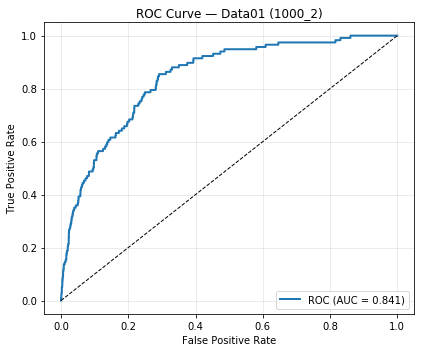

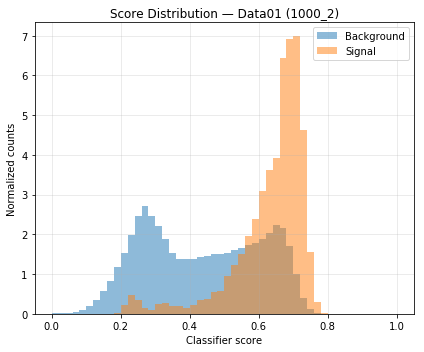


--- Signal mode: 1000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.8540, MaxSIC = 1.7312
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.8567, MaxSIC = 1.6997
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.8681, MaxSIC = 1.8088
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.8539, MaxSIC = 1.7328
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.8670, MaxSIC = 1.8281
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.8541, MaxSIC = 1.7187
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.8506, MaxSIC = 

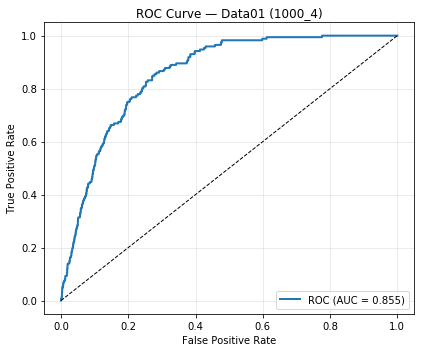

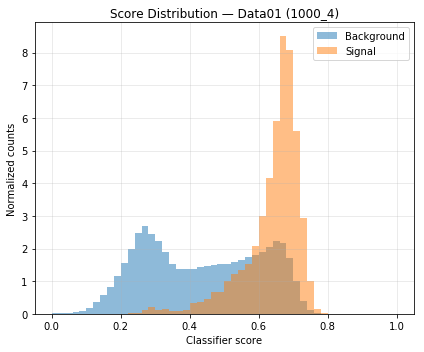


--- Signal mode: 1000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.7989, MaxSIC = 1.4464
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.8000, MaxSIC = 1.4318
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.8113, MaxSIC = 1.4766
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.8013, MaxSIC = 1.4302
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.8077, MaxSIC = 1.4619
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.7933, MaxSIC = 1.4053
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.7897, MaxSIC = 

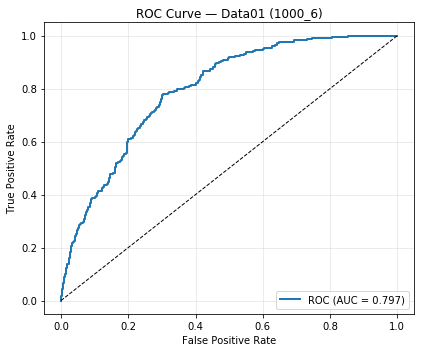

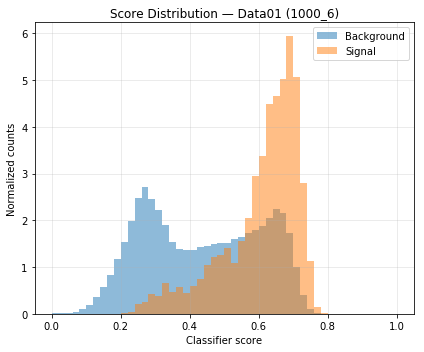


--- Signal mode: 1000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.7795, MaxSIC = 1.3444
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.7757, MaxSIC = 1.3340
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.7921, MaxSIC = 1.3948
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.7757, MaxSIC = 1.3285
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.7847, MaxSIC = 1.3518
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.7680, MaxSIC = 1.2891
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.7688, MaxSIC = 

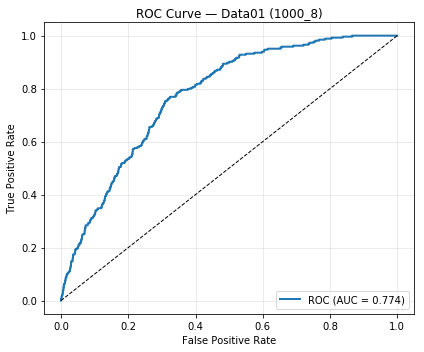

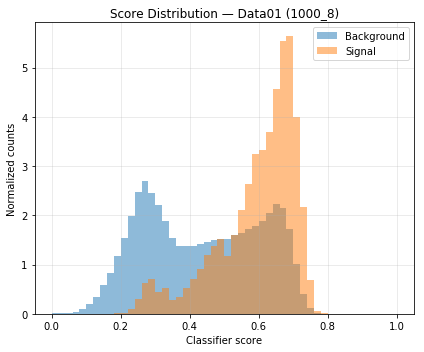


--- Signal mode: 2000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.6798, MaxSIC = 1.1061
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.6797, MaxSIC = 1.1077
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.6866, MaxSIC = 1.1158
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.6812, MaxSIC = 1.1030
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.6834, MaxSIC = 1.1067
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.6757, MaxSIC = 1.1025
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.6763, MaxSIC = 

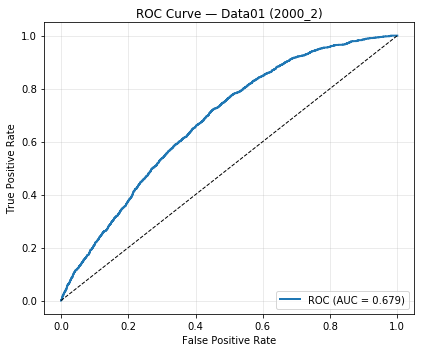

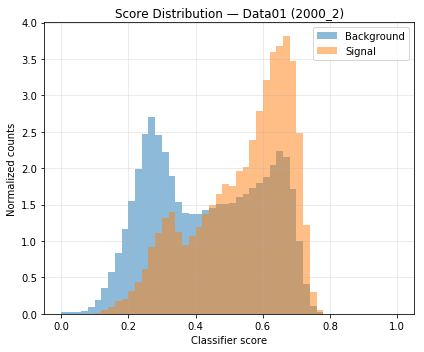


--- Signal mode: 2000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.6875, MaxSIC = 1.1099
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.6876, MaxSIC = 1.1172
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.6952, MaxSIC = 1.1267
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.6901, MaxSIC = 1.1149
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.6913, MaxSIC = 1.1201
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.6860, MaxSIC = 1.1164
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.6836, MaxSIC = 

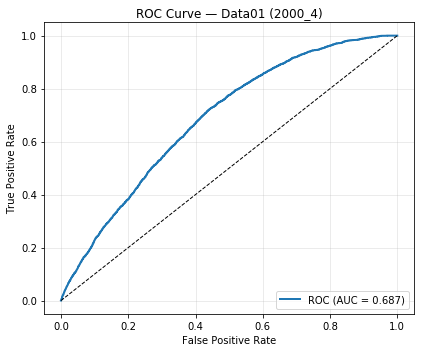

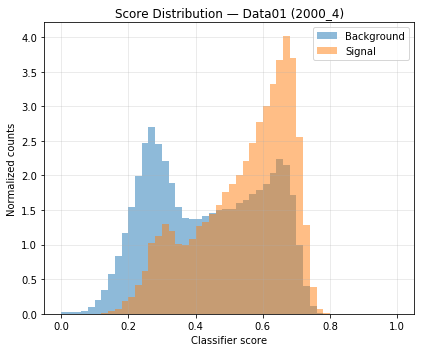


--- Signal mode: 2000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.6938, MaxSIC = 1.1146
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.6922, MaxSIC = 1.1073
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.7009, MaxSIC = 1.1175
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.6935, MaxSIC = 1.1077
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.6963, MaxSIC = 1.1093
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.6892, MaxSIC = 1.1081
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.6877, MaxSIC = 

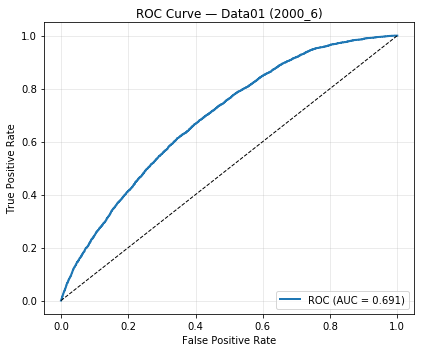

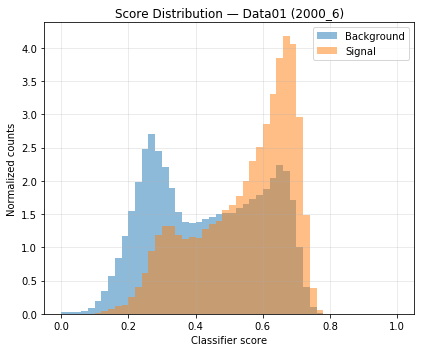


--- Signal mode: 2000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.7059, MaxSIC = 1.1280
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.7042, MaxSIC = 1.1267
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.7117, MaxSIC = 1.1414
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.7054, MaxSIC = 1.1258
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.7084, MaxSIC = 1.1288
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.7014, MaxSIC = 1.1236
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.6995, MaxSIC = 

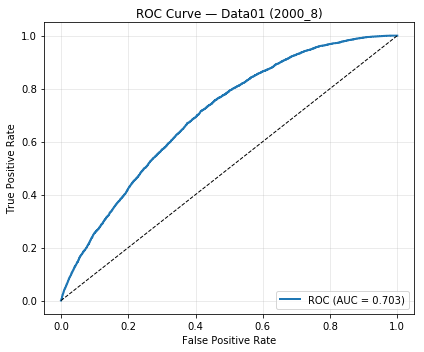

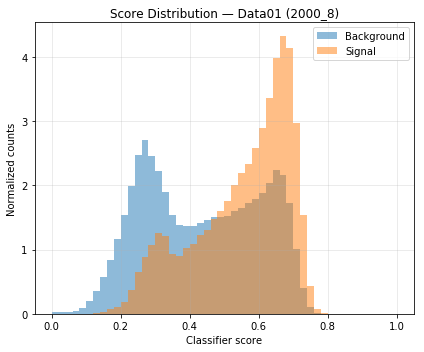


--- Signal mode: 3000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.5229, MaxSIC = 1.0026
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.5196, MaxSIC = 1.0047
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.5271, MaxSIC = 1.0046
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.5280, MaxSIC = 1.0028
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.5285, MaxSIC = 1.0027
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.5249, MaxSIC = 1.0020
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.5235, MaxSIC = 

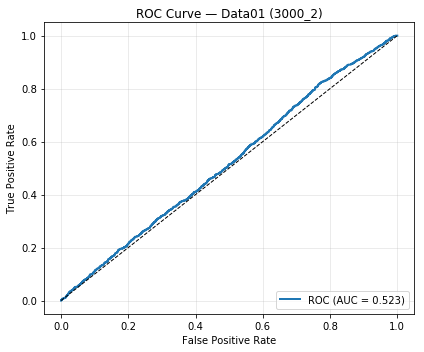

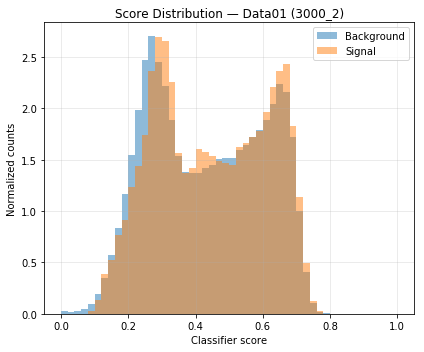


--- Signal mode: 3000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.5469, MaxSIC = 1.0020
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.5477, MaxSIC = 1.0055
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.5537, MaxSIC = 1.0056
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.5526, MaxSIC = 1.0026
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.5543, MaxSIC = 1.0042
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.5484, MaxSIC = 1.0009
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.5475, MaxSIC = 

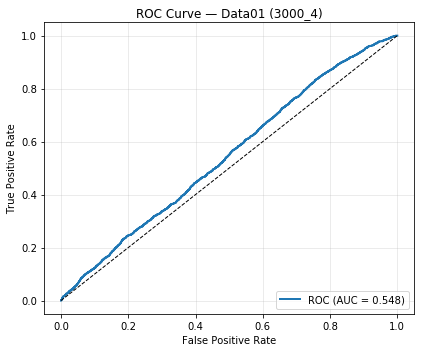

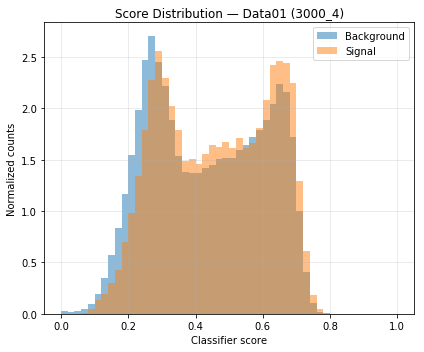


--- Signal mode: 3000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.5937, MaxSIC = 1.0141
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.5934, MaxSIC = 1.0143
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.6000, MaxSIC = 1.0159
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.5986, MaxSIC = 1.0156
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.5988, MaxSIC = 1.0175
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.5923, MaxSIC = 1.0134
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.5925, MaxSIC = 

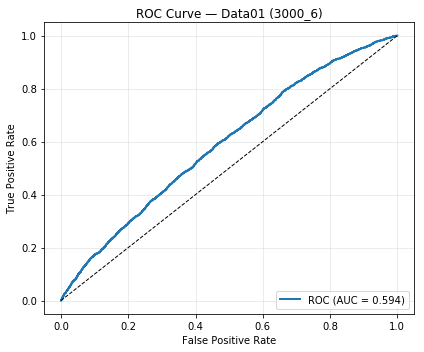

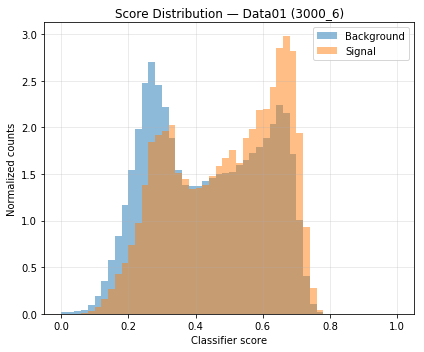


--- Signal mode: 3000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.6137, MaxSIC = 1.0372
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.6113, MaxSIC = 1.0339
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.6185, MaxSIC = 1.0325
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.6153, MaxSIC = 1.0295
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.6165, MaxSIC = 1.0329
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.6104, MaxSIC = 1.0345
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.6103, MaxSIC = 

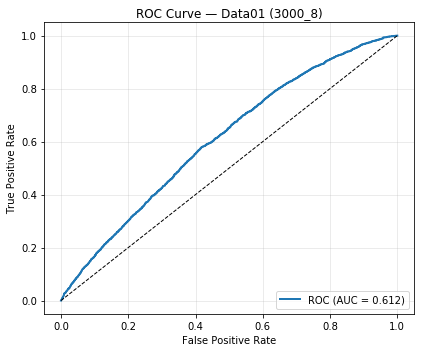

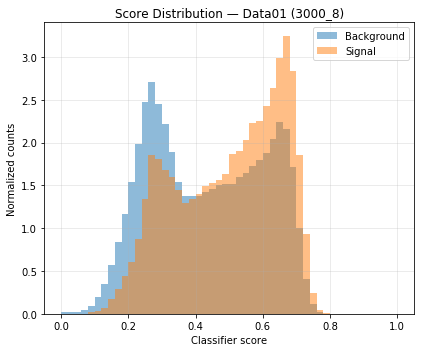


=== Evaluating models for Data02 ===

--- Signal mode: 1000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.8357, MaxSIC = 1.6471
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.8480, MaxSIC = 1.7804
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.8455, MaxSIC = 1.7153
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.8466, MaxSIC = 1.9489
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.8499, MaxSIC = 2.0340
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.8425, MaxSIC = 2.0103
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_

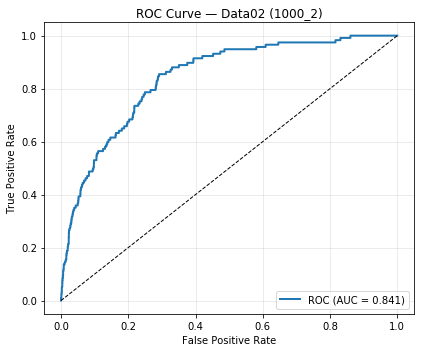

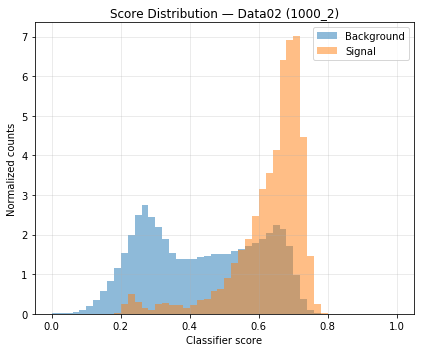


--- Signal mode: 1000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.8522, MaxSIC = 1.6954
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.8567, MaxSIC = 1.6997
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.8681, MaxSIC = 1.8088
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.8539, MaxSIC = 1.7328
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.8670, MaxSIC = 1.8281
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.8541, MaxSIC = 1.7187
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.8506, MaxSIC = 

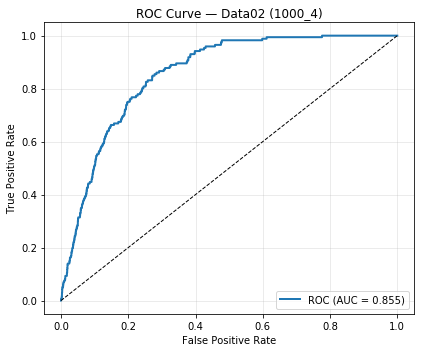

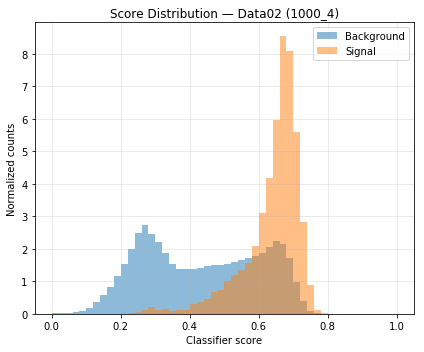


--- Signal mode: 1000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.7970, MaxSIC = 1.3827
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.8000, MaxSIC = 1.4318
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.8113, MaxSIC = 1.4766
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.8013, MaxSIC = 1.4302
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.8077, MaxSIC = 1.4619
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.7933, MaxSIC = 1.4053
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.7897, MaxSIC = 

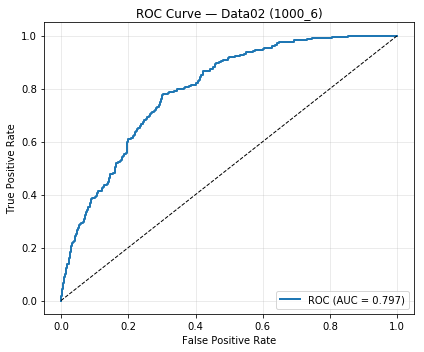

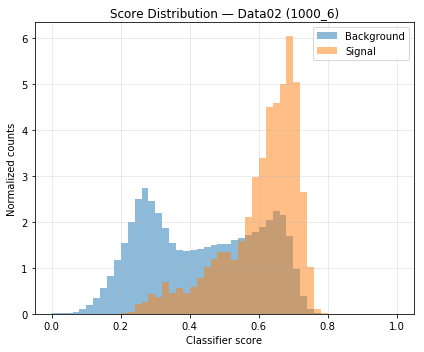


--- Signal mode: 1000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.7761, MaxSIC = 1.3291
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.7757, MaxSIC = 1.3340
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.7921, MaxSIC = 1.3948
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.7757, MaxSIC = 1.3285
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.7847, MaxSIC = 1.3518
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.7680, MaxSIC = 1.2891
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.7688, MaxSIC = 

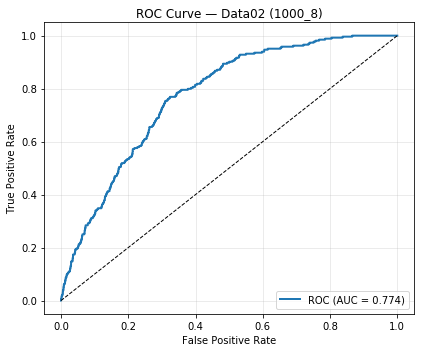

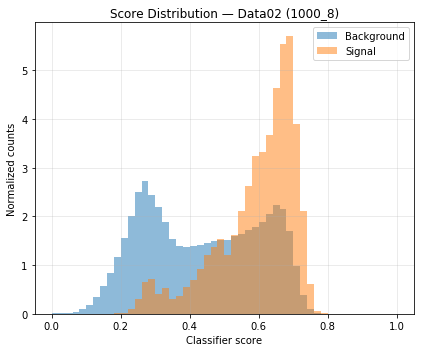


--- Signal mode: 2000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.6785, MaxSIC = 1.1011
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.6797, MaxSIC = 1.1077
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.6866, MaxSIC = 1.1158
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.6812, MaxSIC = 1.1030
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.6834, MaxSIC = 1.1067
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.6757, MaxSIC = 1.1025
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.6763, MaxSIC = 

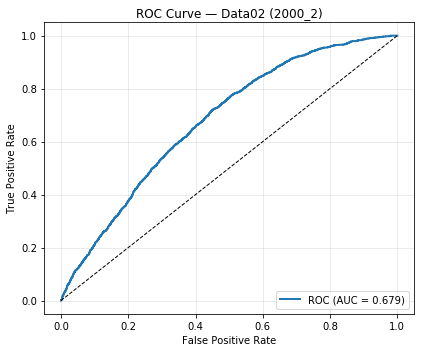

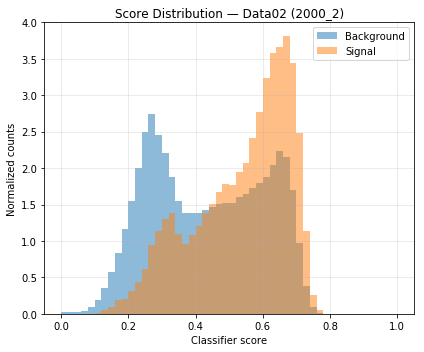


--- Signal mode: 2000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.6853, MaxSIC = 1.1085
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.6876, MaxSIC = 1.1172
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.6952, MaxSIC = 1.1267
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.6901, MaxSIC = 1.1149
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.6913, MaxSIC = 1.1201
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.6860, MaxSIC = 1.1164
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.6836, MaxSIC = 

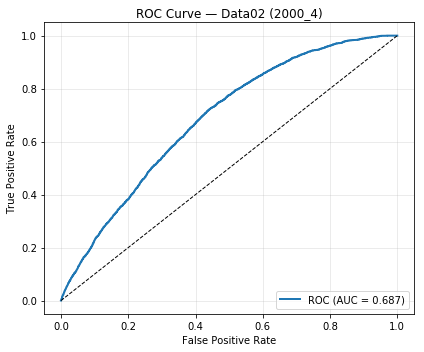

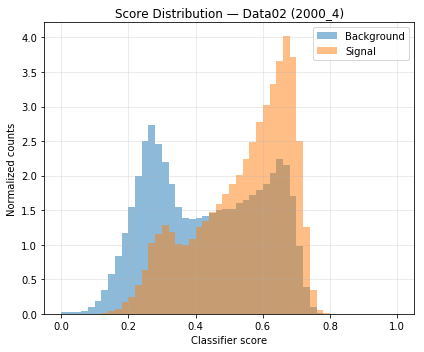


--- Signal mode: 2000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.6897, MaxSIC = 1.1003
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.6922, MaxSIC = 1.1073
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.7009, MaxSIC = 1.1175
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.6935, MaxSIC = 1.1077
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.6963, MaxSIC = 1.1093
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.6892, MaxSIC = 1.1081
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.6877, MaxSIC = 

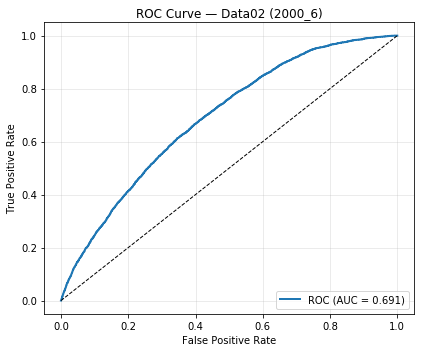

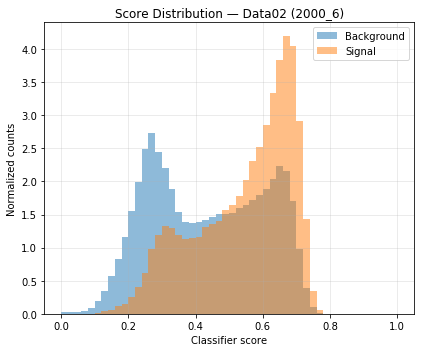


--- Signal mode: 2000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.7024, MaxSIC = 1.1285
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.7042, MaxSIC = 1.1267
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.7117, MaxSIC = 1.1414
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.7054, MaxSIC = 1.1258
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.7084, MaxSIC = 1.1288
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.7014, MaxSIC = 1.1236
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.6995, MaxSIC = 

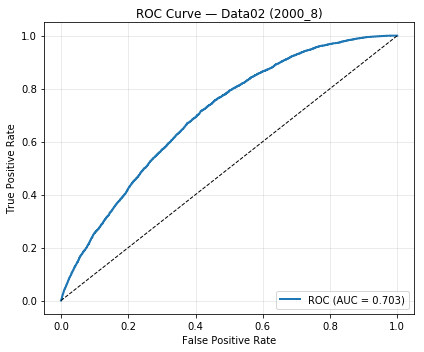

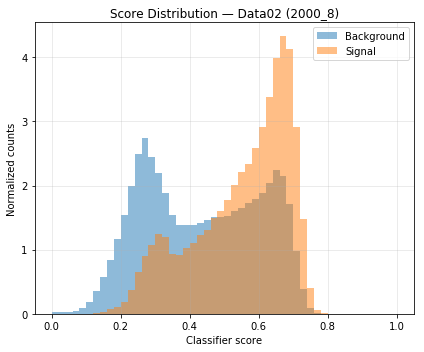


--- Signal mode: 3000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.5218, MaxSIC = 1.0028
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.5196, MaxSIC = 1.0047
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.5271, MaxSIC = 1.0046
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.5280, MaxSIC = 1.0028
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.5285, MaxSIC = 1.0027
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.5249, MaxSIC = 1.0020
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.5235, MaxSIC = 

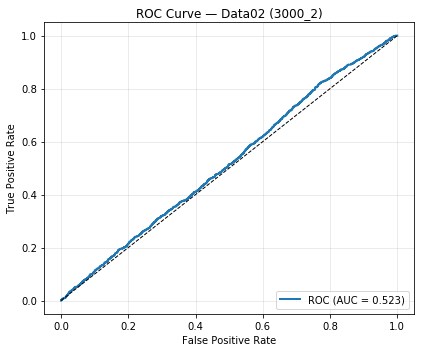

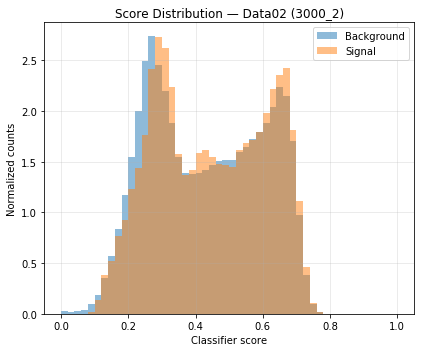


--- Signal mode: 3000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.5475, MaxSIC = 1.0013
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.5477, MaxSIC = 1.0055
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.5537, MaxSIC = 1.0056
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.5526, MaxSIC = 1.0026
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.5543, MaxSIC = 1.0042
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.5484, MaxSIC = 1.0009
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.5475, MaxSIC = 

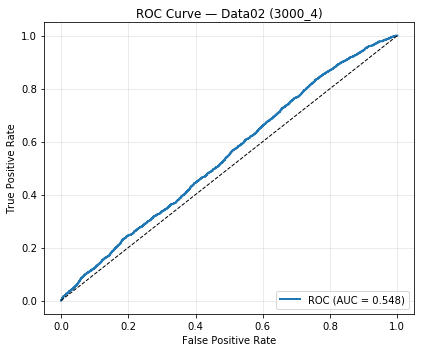

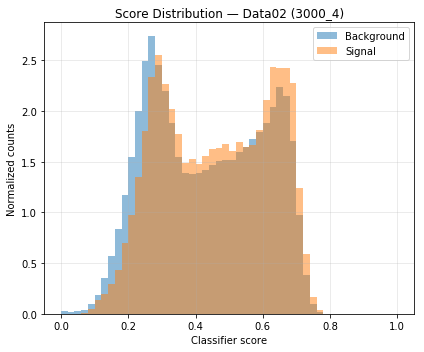


--- Signal mode: 3000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.5941, MaxSIC = 1.0105
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.5934, MaxSIC = 1.0143
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.6000, MaxSIC = 1.0159
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.5986, MaxSIC = 1.0156
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.5988, MaxSIC = 1.0175
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.5923, MaxSIC = 1.0134
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.5925, MaxSIC = 

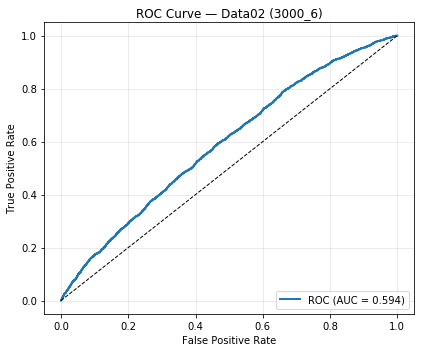

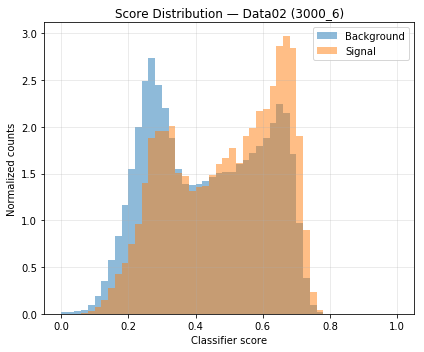


--- Signal mode: 3000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.6121, MaxSIC = 1.0320
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.6113, MaxSIC = 1.0339
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.6185, MaxSIC = 1.0325
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.6153, MaxSIC = 1.0295
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.6165, MaxSIC = 1.0329
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.6104, MaxSIC = 1.0345
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.6103, MaxSIC = 

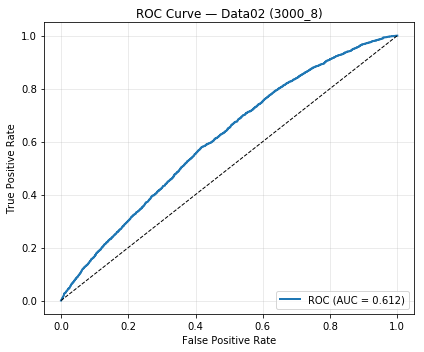

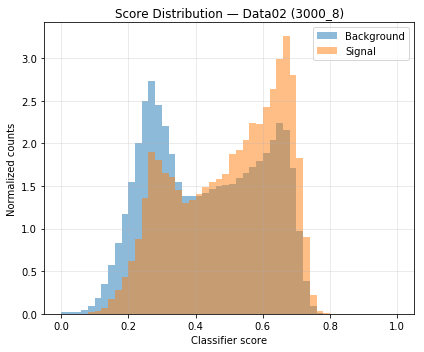


=== Evaluating models for Data03 ===

--- Signal mode: 1000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.8357, MaxSIC = 1.6471
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.8480, MaxSIC = 1.7804
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.8455, MaxSIC = 1.7153
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.8466, MaxSIC = 1.9489
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.8499, MaxSIC = 2.0340
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.8425, MaxSIC = 2.0103
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_

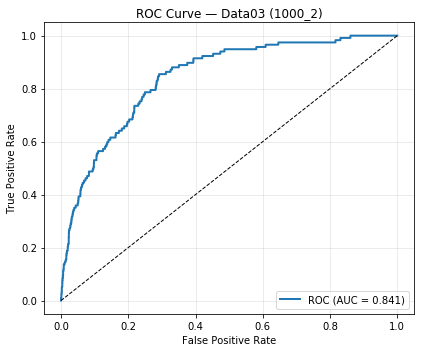

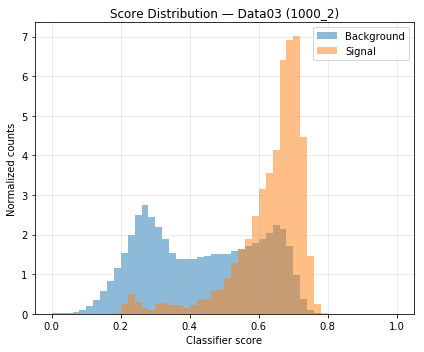


--- Signal mode: 1000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.8522, MaxSIC = 1.6954
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.8567, MaxSIC = 1.6997
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.8681, MaxSIC = 1.8088
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.8539, MaxSIC = 1.7328
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.8670, MaxSIC = 1.8281
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.8541, MaxSIC = 1.7187
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.8506, MaxSIC = 

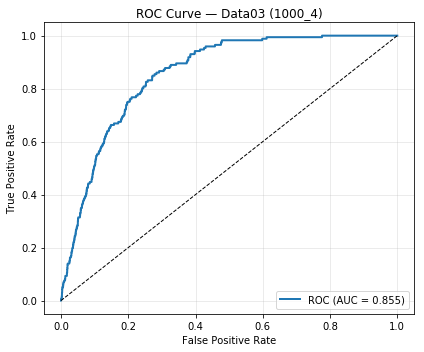

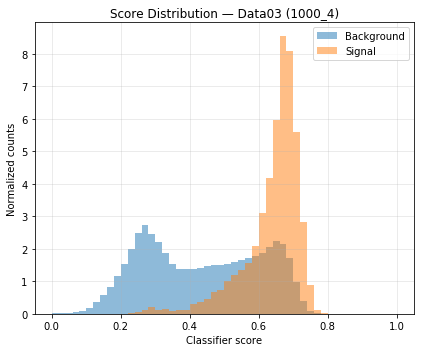


--- Signal mode: 1000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.7970, MaxSIC = 1.3827
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.8000, MaxSIC = 1.4318
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.8113, MaxSIC = 1.4766
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.8013, MaxSIC = 1.4302
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.8077, MaxSIC = 1.4619
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.7933, MaxSIC = 1.4053
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.7897, MaxSIC = 

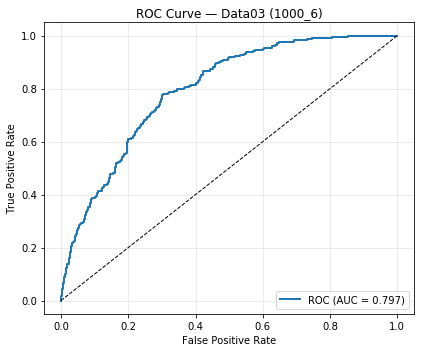

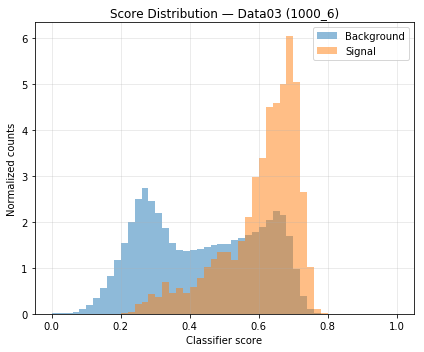


--- Signal mode: 1000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.7761, MaxSIC = 1.3291
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.7757, MaxSIC = 1.3340
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.7921, MaxSIC = 1.3948
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.7757, MaxSIC = 1.3285
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.7847, MaxSIC = 1.3518
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.7680, MaxSIC = 1.2891
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.7688, MaxSIC = 

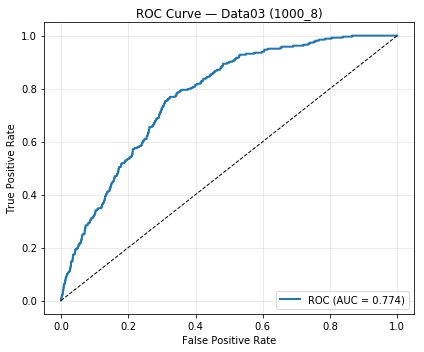

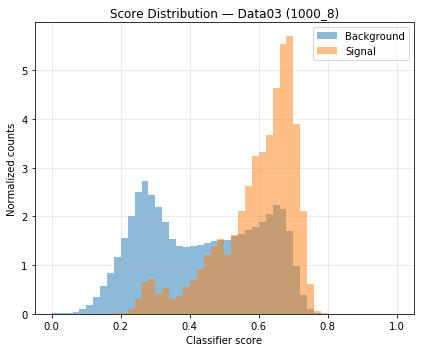


--- Signal mode: 2000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.6785, MaxSIC = 1.1011
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.6797, MaxSIC = 1.1077
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.6866, MaxSIC = 1.1158
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.6812, MaxSIC = 1.1030
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.6834, MaxSIC = 1.1067
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.6757, MaxSIC = 1.1025
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.6763, MaxSIC = 

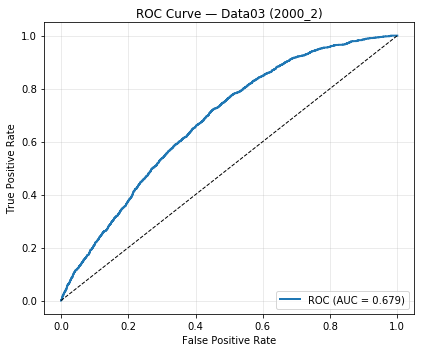

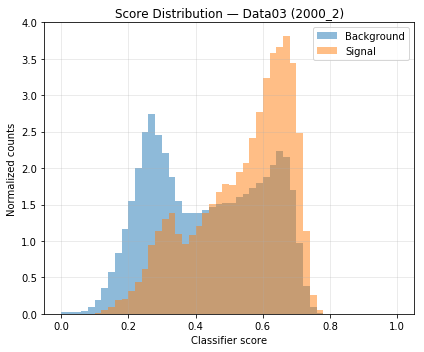


--- Signal mode: 2000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.6853, MaxSIC = 1.1085
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.6876, MaxSIC = 1.1172
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.6952, MaxSIC = 1.1267
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.6901, MaxSIC = 1.1149
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.6913, MaxSIC = 1.1201
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.6860, MaxSIC = 1.1164
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.6836, MaxSIC = 

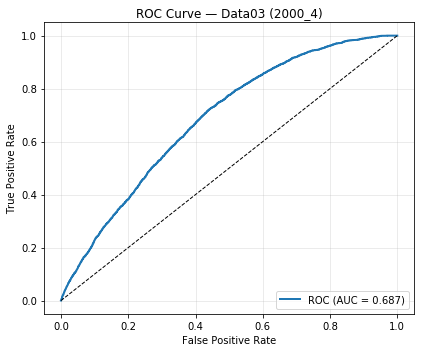

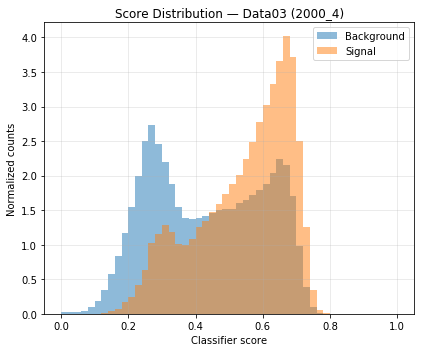


--- Signal mode: 2000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.6897, MaxSIC = 1.1003
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.6922, MaxSIC = 1.1073
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.7009, MaxSIC = 1.1175
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.6935, MaxSIC = 1.1077
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.6963, MaxSIC = 1.1093
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.6892, MaxSIC = 1.1081
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.6877, MaxSIC = 

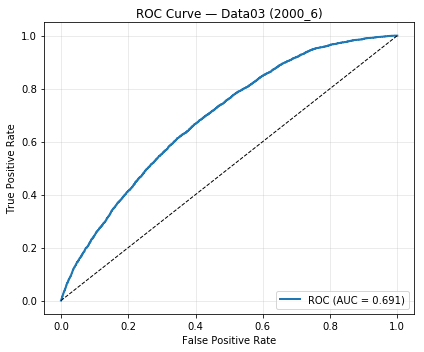

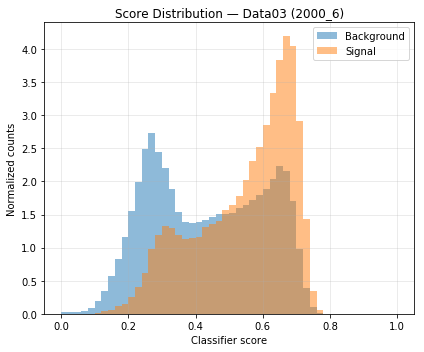


--- Signal mode: 2000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.7024, MaxSIC = 1.1285
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.7042, MaxSIC = 1.1267
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.7117, MaxSIC = 1.1414
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.7054, MaxSIC = 1.1258
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.7084, MaxSIC = 1.1288
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.7014, MaxSIC = 1.1236
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.6995, MaxSIC = 

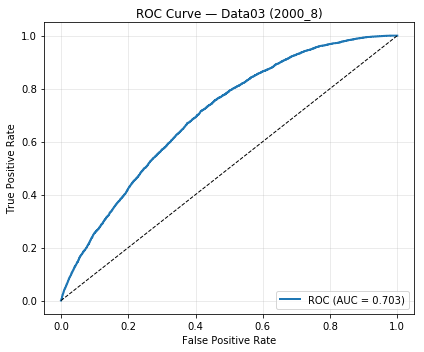

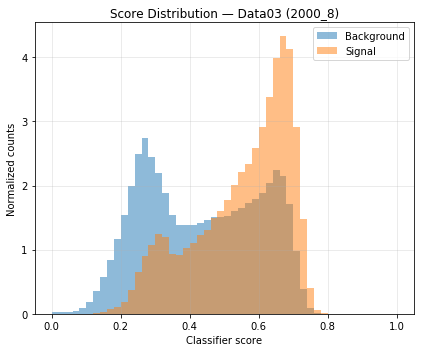


--- Signal mode: 3000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.5218, MaxSIC = 1.0028
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.5196, MaxSIC = 1.0047
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.5271, MaxSIC = 1.0046
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.5280, MaxSIC = 1.0028
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.5285, MaxSIC = 1.0027
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.5249, MaxSIC = 1.0020
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.5235, MaxSIC = 

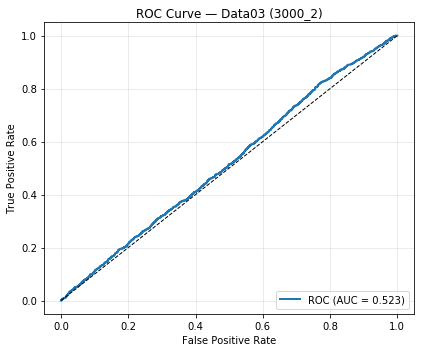

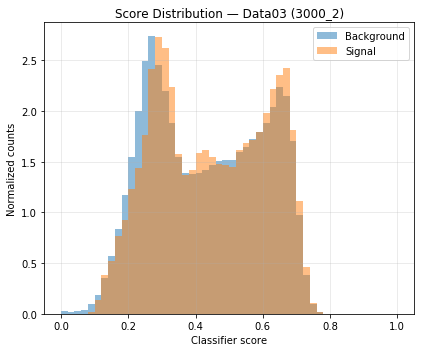


--- Signal mode: 3000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.5475, MaxSIC = 1.0013
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.5477, MaxSIC = 1.0055
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.5537, MaxSIC = 1.0056
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.5526, MaxSIC = 1.0026
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.5543, MaxSIC = 1.0042
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.5484, MaxSIC = 1.0009
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.5475, MaxSIC = 

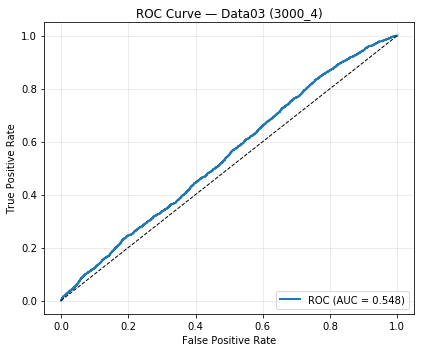

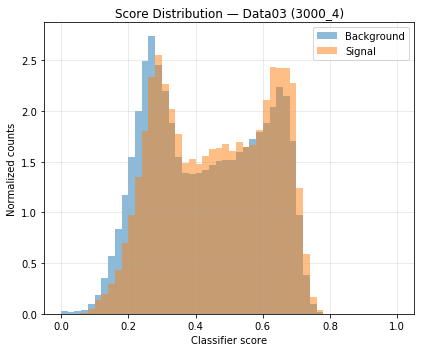


--- Signal mode: 3000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.5941, MaxSIC = 1.0105
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.5934, MaxSIC = 1.0143
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.6000, MaxSIC = 1.0159
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.5986, MaxSIC = 1.0156
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.5988, MaxSIC = 1.0175
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.5923, MaxSIC = 1.0134
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.5925, MaxSIC = 

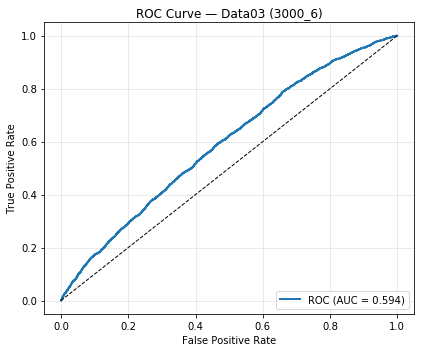

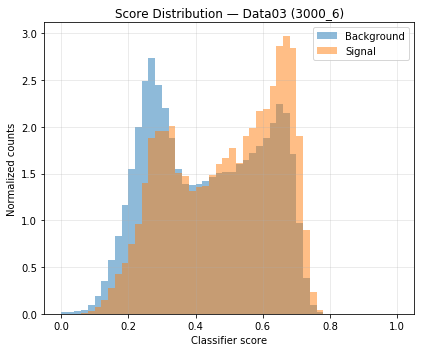


--- Signal mode: 3000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.6121, MaxSIC = 1.0320
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.6113, MaxSIC = 1.0339
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.6185, MaxSIC = 1.0325
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.6153, MaxSIC = 1.0295
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.6165, MaxSIC = 1.0329
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.6104, MaxSIC = 1.0345
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.6103, MaxSIC = 

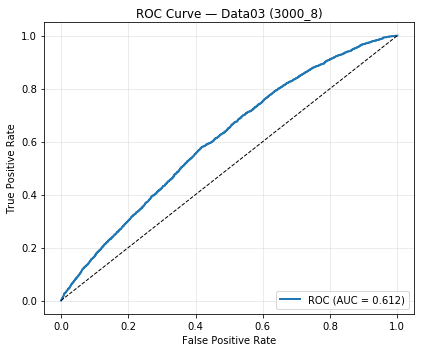

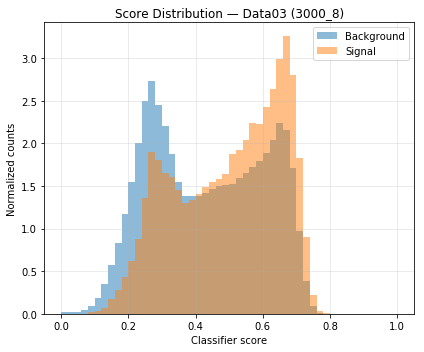


=== Evaluating models for Data04 ===

--- Signal mode: 1000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.8357, MaxSIC = 1.6471
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.8480, MaxSIC = 1.7804
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.8455, MaxSIC = 1.7153
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.8466, MaxSIC = 1.9489
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.8499, MaxSIC = 2.0340
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.8425, MaxSIC = 2.0103
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_

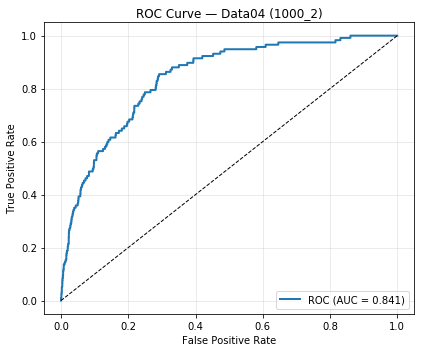

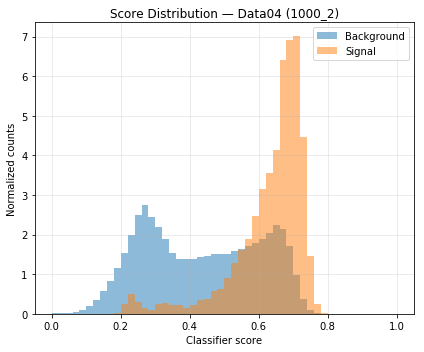


--- Signal mode: 1000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.8522, MaxSIC = 1.6954
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.8567, MaxSIC = 1.6997
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.8681, MaxSIC = 1.8088
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.8539, MaxSIC = 1.7328
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.8670, MaxSIC = 1.8281
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.8541, MaxSIC = 1.7187
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.8506, MaxSIC = 

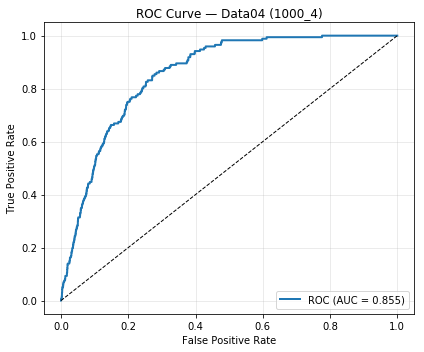

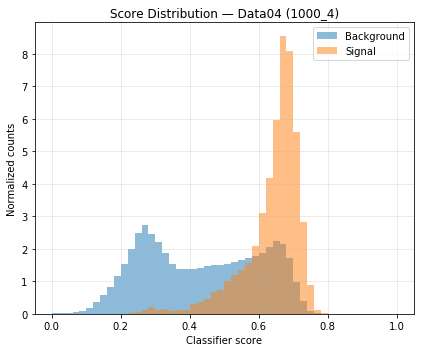


--- Signal mode: 1000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.7970, MaxSIC = 1.3827
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.8000, MaxSIC = 1.4318
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.8113, MaxSIC = 1.4766
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.8013, MaxSIC = 1.4302
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.8077, MaxSIC = 1.4619
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.7933, MaxSIC = 1.4053
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.7897, MaxSIC = 

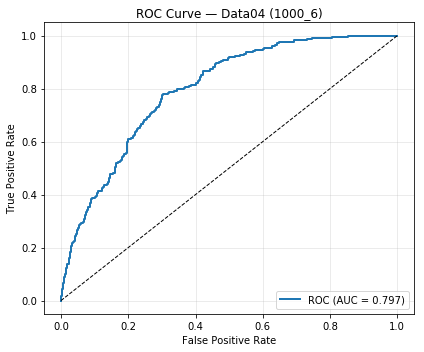

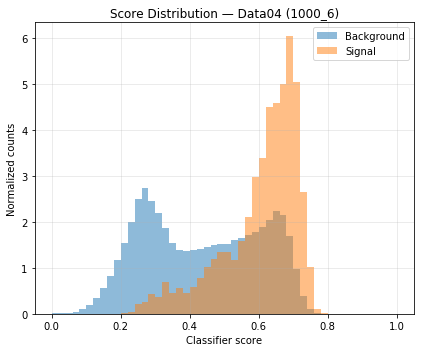


--- Signal mode: 1000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.7761, MaxSIC = 1.3291
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.7757, MaxSIC = 1.3340
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.7921, MaxSIC = 1.3948
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.7757, MaxSIC = 1.3285
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.7847, MaxSIC = 1.3518
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.7680, MaxSIC = 1.2891
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.7688, MaxSIC = 

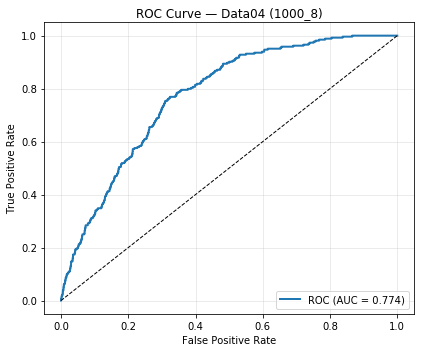

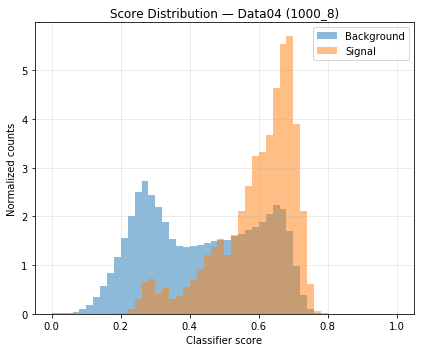


--- Signal mode: 2000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.6785, MaxSIC = 1.1011
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.6797, MaxSIC = 1.1077
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.6866, MaxSIC = 1.1158
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.6812, MaxSIC = 1.1030
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.6834, MaxSIC = 1.1067
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.6757, MaxSIC = 1.1025
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.6763, MaxSIC = 

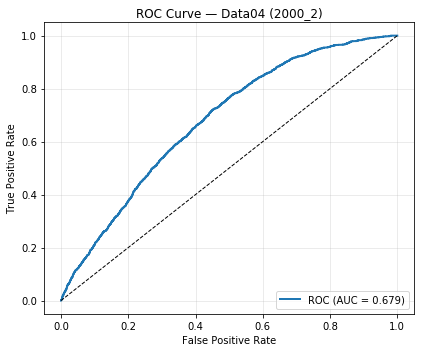

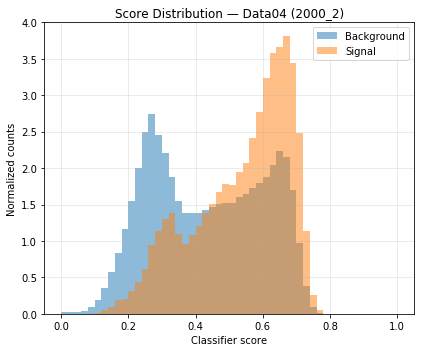


--- Signal mode: 2000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.6853, MaxSIC = 1.1085
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.6876, MaxSIC = 1.1172
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.6952, MaxSIC = 1.1267
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.6901, MaxSIC = 1.1149
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.6913, MaxSIC = 1.1201
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.6860, MaxSIC = 1.1164
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.6836, MaxSIC = 

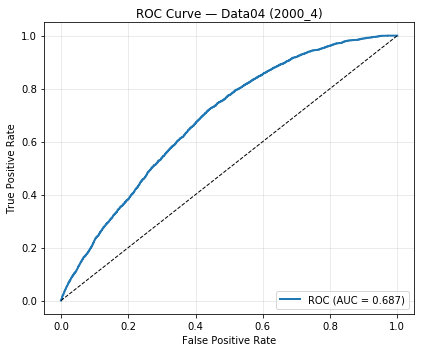

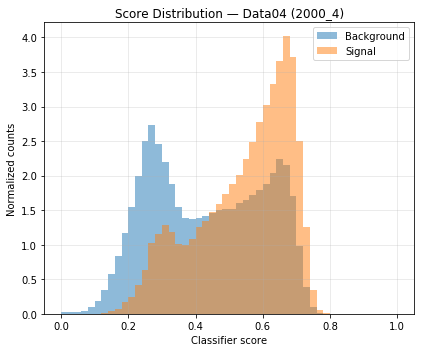


--- Signal mode: 2000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.6897, MaxSIC = 1.1003
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.6922, MaxSIC = 1.1073
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.7009, MaxSIC = 1.1175
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.6935, MaxSIC = 1.1077
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.6963, MaxSIC = 1.1093
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.6892, MaxSIC = 1.1081
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.6877, MaxSIC = 

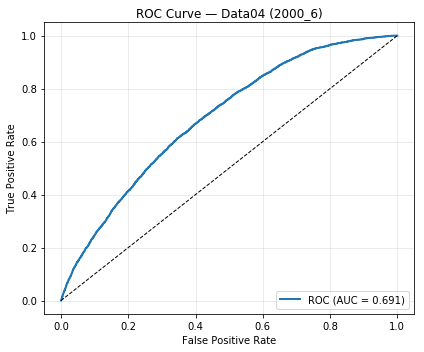

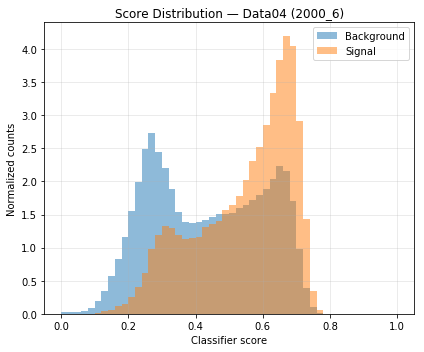


--- Signal mode: 2000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.7024, MaxSIC = 1.1285
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.7042, MaxSIC = 1.1267
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.7117, MaxSIC = 1.1414
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.7054, MaxSIC = 1.1258
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.7084, MaxSIC = 1.1288
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.7014, MaxSIC = 1.1236
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.6995, MaxSIC = 

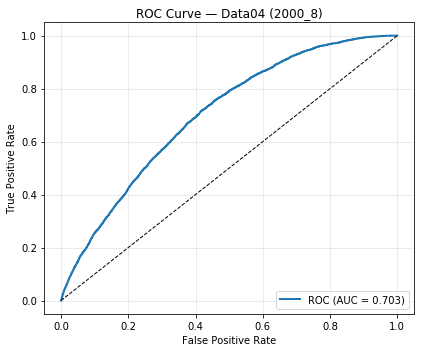

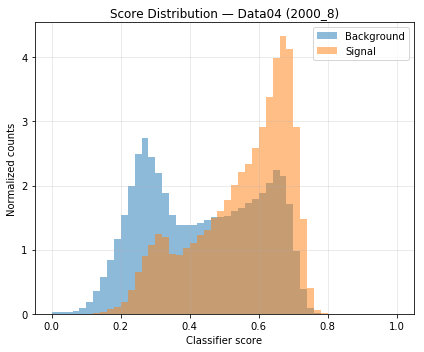


--- Signal mode: 3000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.5218, MaxSIC = 1.0028
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.5196, MaxSIC = 1.0047
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.5271, MaxSIC = 1.0046
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.5280, MaxSIC = 1.0028
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.5285, MaxSIC = 1.0027
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.5249, MaxSIC = 1.0020
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.5235, MaxSIC = 

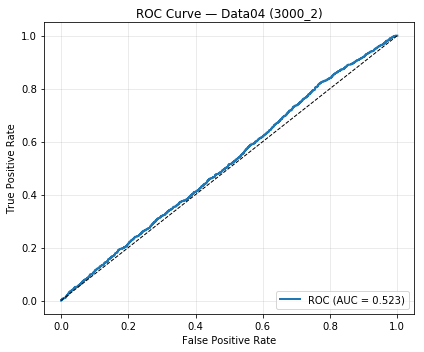

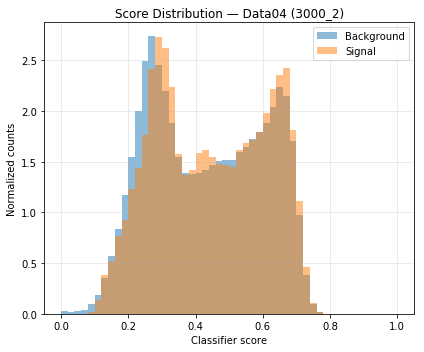


--- Signal mode: 3000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.5475, MaxSIC = 1.0013
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.5477, MaxSIC = 1.0055
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.5537, MaxSIC = 1.0056
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.5526, MaxSIC = 1.0026
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.5543, MaxSIC = 1.0042
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.5484, MaxSIC = 1.0009
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.5475, MaxSIC = 

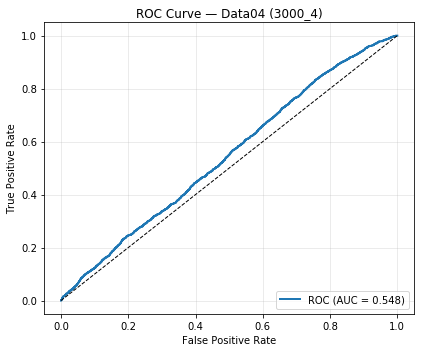

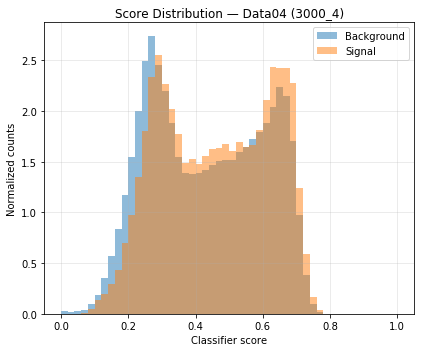


--- Signal mode: 3000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.5941, MaxSIC = 1.0105
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.5934, MaxSIC = 1.0143
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.6000, MaxSIC = 1.0159
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.5986, MaxSIC = 1.0156
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.5988, MaxSIC = 1.0175
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.5923, MaxSIC = 1.0134
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.5925, MaxSIC = 

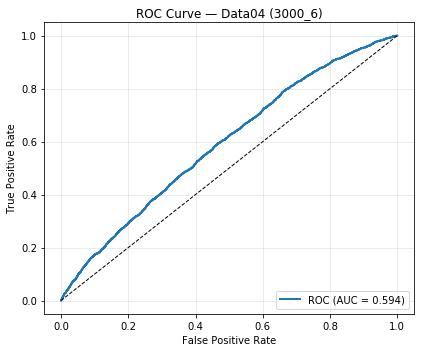

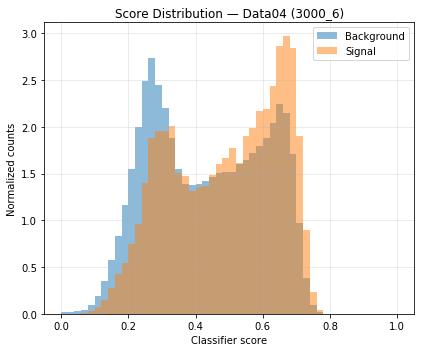


--- Signal mode: 3000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.6121, MaxSIC = 1.0320
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.6113, MaxSIC = 1.0339
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.6185, MaxSIC = 1.0325
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.6153, MaxSIC = 1.0295
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.6165, MaxSIC = 1.0329
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.6104, MaxSIC = 1.0345
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.6103, MaxSIC = 

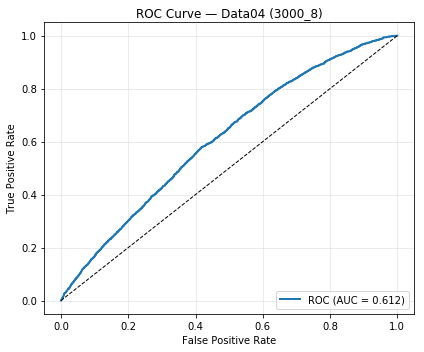

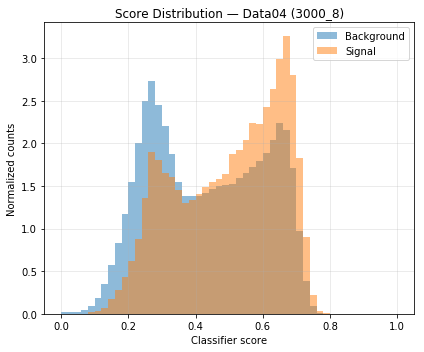


=== Evaluating models for Data05 ===

--- Signal mode: 1000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.8357, MaxSIC = 1.6471
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.8480, MaxSIC = 1.7804
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.8455, MaxSIC = 1.7153
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.8466, MaxSIC = 1.9489
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.8499, MaxSIC = 2.0340
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.8425, MaxSIC = 2.0103
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_

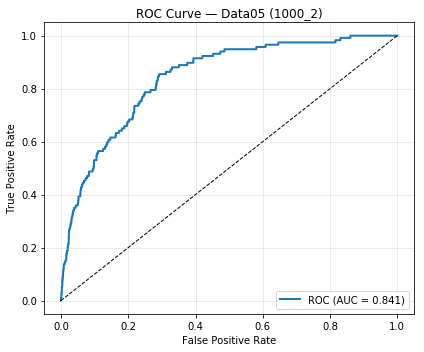

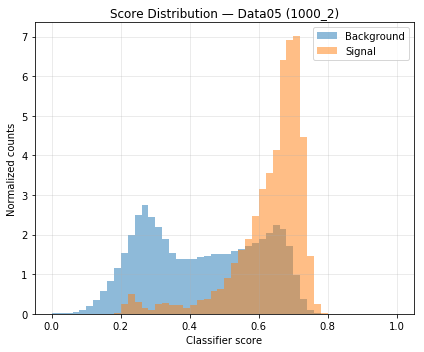


--- Signal mode: 1000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.8522, MaxSIC = 1.6954
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.8567, MaxSIC = 1.6997
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.8681, MaxSIC = 1.8088
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.8539, MaxSIC = 1.7328
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.8670, MaxSIC = 1.8281
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.8541, MaxSIC = 1.7187
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.8506, MaxSIC = 

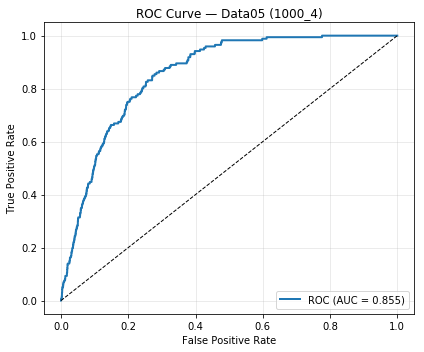

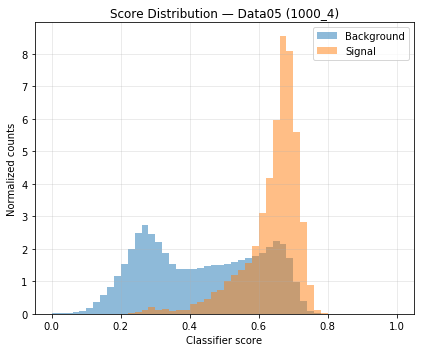


--- Signal mode: 1000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.7970, MaxSIC = 1.3827
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.8000, MaxSIC = 1.4318
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.8113, MaxSIC = 1.4766
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.8013, MaxSIC = 1.4302
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.8077, MaxSIC = 1.4619
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.7933, MaxSIC = 1.4053
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.7897, MaxSIC = 

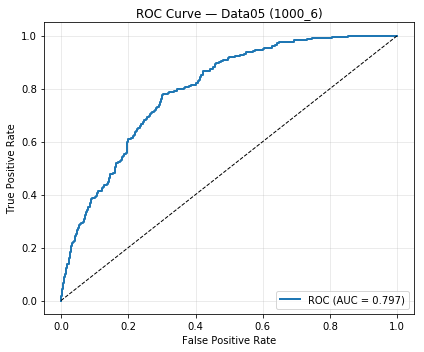

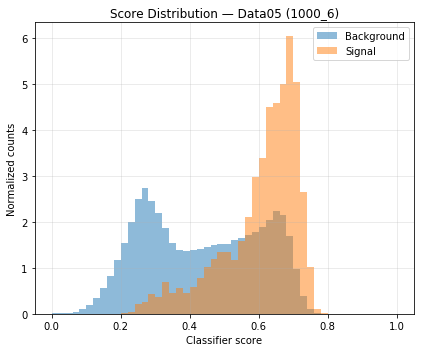


--- Signal mode: 1000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.7761, MaxSIC = 1.3291
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.7757, MaxSIC = 1.3340
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.7921, MaxSIC = 1.3948
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.7757, MaxSIC = 1.3285
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.7847, MaxSIC = 1.3518
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.7680, MaxSIC = 1.2891
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.7688, MaxSIC = 

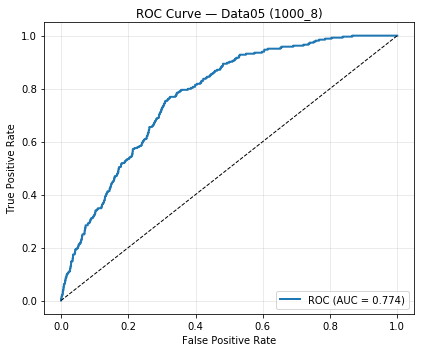

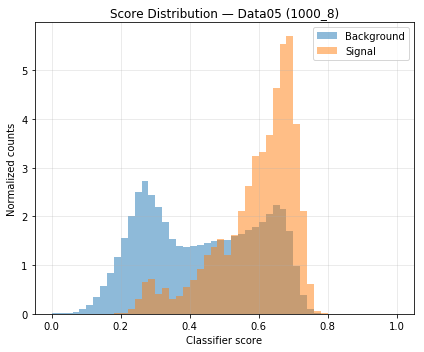


--- Signal mode: 2000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.6785, MaxSIC = 1.1011
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.6797, MaxSIC = 1.1077
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.6866, MaxSIC = 1.1158
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.6812, MaxSIC = 1.1030
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.6834, MaxSIC = 1.1067
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.6757, MaxSIC = 1.1025
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.6763, MaxSIC = 

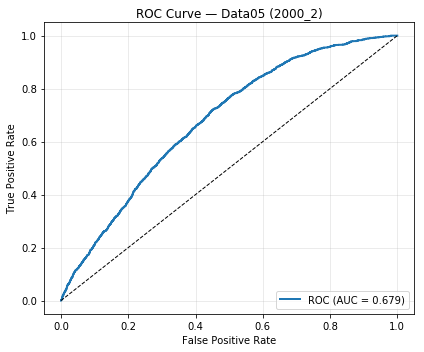

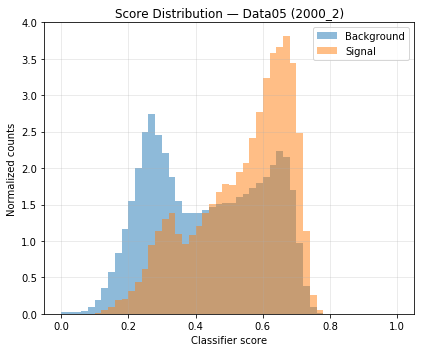


--- Signal mode: 2000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.6853, MaxSIC = 1.1085
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.6876, MaxSIC = 1.1172
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.6952, MaxSIC = 1.1267
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.6901, MaxSIC = 1.1149
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.6913, MaxSIC = 1.1201
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.6860, MaxSIC = 1.1164
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.6836, MaxSIC = 

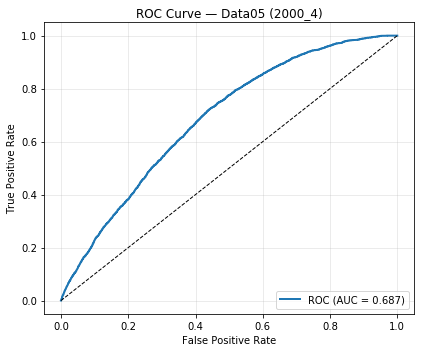

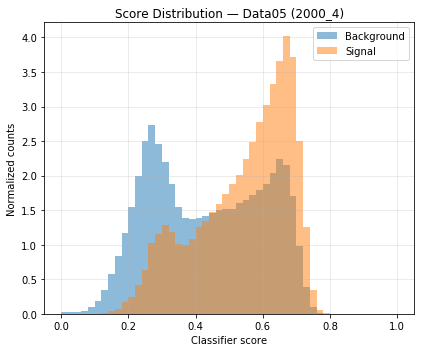


--- Signal mode: 2000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.6897, MaxSIC = 1.1003
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.6922, MaxSIC = 1.1073
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.7009, MaxSIC = 1.1175
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.6935, MaxSIC = 1.1077
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.6963, MaxSIC = 1.1093
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.6892, MaxSIC = 1.1081
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.6877, MaxSIC = 

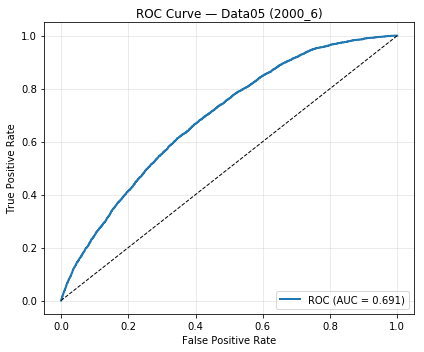

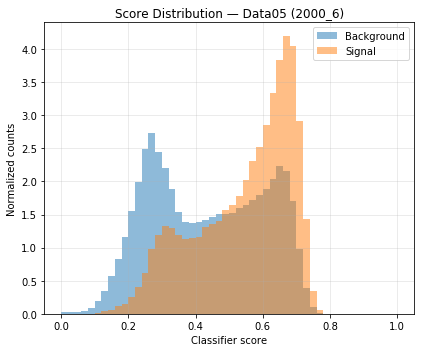


--- Signal mode: 2000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.7024, MaxSIC = 1.1285
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.7042, MaxSIC = 1.1267
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.7117, MaxSIC = 1.1414
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.7054, MaxSIC = 1.1258
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.7084, MaxSIC = 1.1288
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.7014, MaxSIC = 1.1236
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.6995, MaxSIC = 

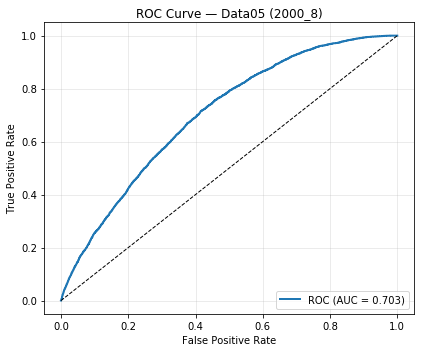

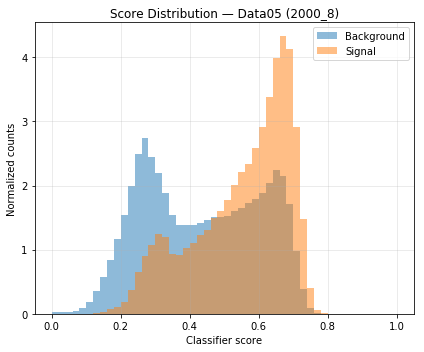


--- Signal mode: 3000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.5218, MaxSIC = 1.0028
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.5196, MaxSIC = 1.0047
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.5271, MaxSIC = 1.0046
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.5280, MaxSIC = 1.0028
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.5285, MaxSIC = 1.0027
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.5249, MaxSIC = 1.0020
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.5235, MaxSIC = 

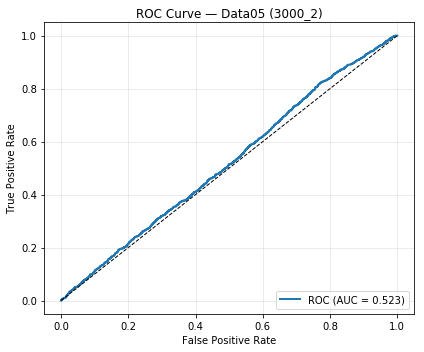

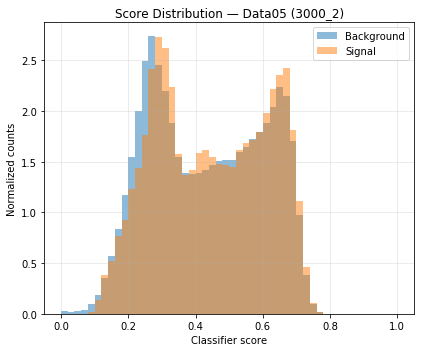


--- Signal mode: 3000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.5475, MaxSIC = 1.0013
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.5477, MaxSIC = 1.0055
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.5537, MaxSIC = 1.0056
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.5526, MaxSIC = 1.0026
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.5543, MaxSIC = 1.0042
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.5484, MaxSIC = 1.0009
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.5475, MaxSIC = 

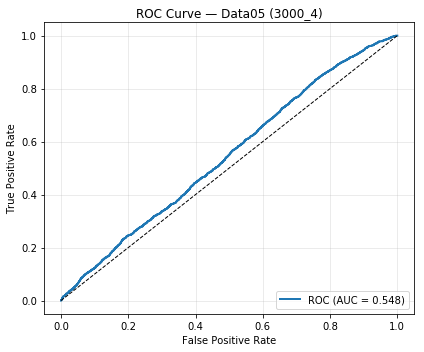

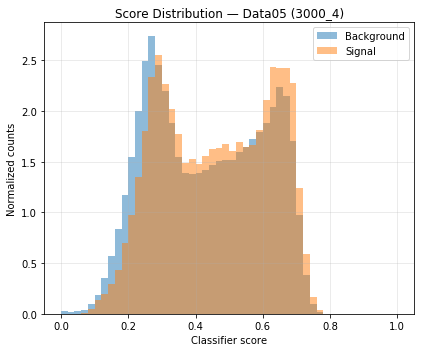


--- Signal mode: 3000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.5941, MaxSIC = 1.0105
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.5934, MaxSIC = 1.0143
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.6000, MaxSIC = 1.0159
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.5986, MaxSIC = 1.0156
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.5988, MaxSIC = 1.0175
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.5923, MaxSIC = 1.0134
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.5925, MaxSIC = 

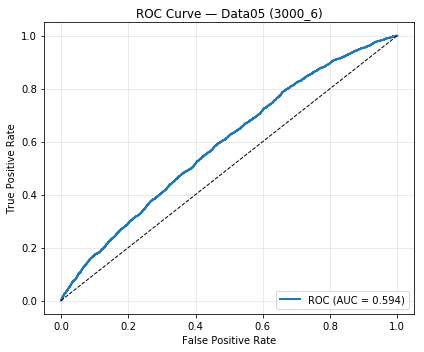

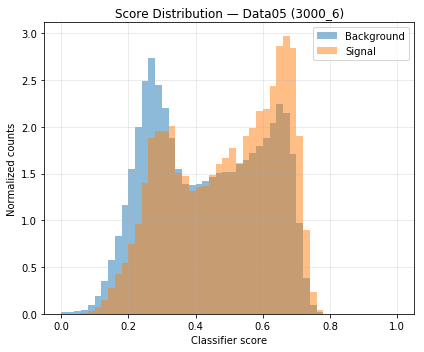


--- Signal mode: 3000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.6121, MaxSIC = 1.0320
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.6113, MaxSIC = 1.0339
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.6185, MaxSIC = 1.0325
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.6153, MaxSIC = 1.0295
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.6165, MaxSIC = 1.0329
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.6104, MaxSIC = 1.0345
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.6103, MaxSIC = 

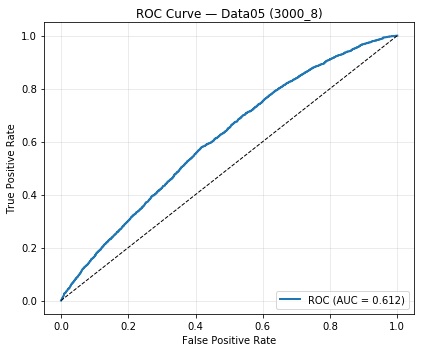

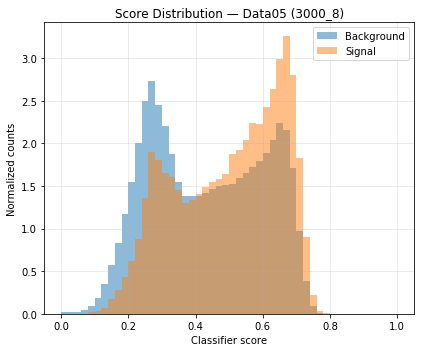


=== ✅ Evaluation complete ===


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
# -----------------------------
# Evaluation Loop
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# results = {}

n_context = 2
n_runs = 20

results = {}          # stores AUCs
maxsic_results = {}   # stores maxSIC values

n_context = 2  # skip first 2 columns → use last 5 features

for dataset, model_paths in reweight_models_paths.items():
    print(f"\n=== Evaluating models for {dataset} ===")

    results[dataset] = {}
    maxsic_results[dataset] = {}

    for mode in signal_modes:
        print(f"\n--- Signal mode: {mode} ---")

        model_aucs = []
        model_maxsics = []
        all_scores_sig = []
        all_scores_bkg = []
        # Loop over all 20 runs for this dataset
        for run in range(n_runs):
            if run >= len(model_paths):
                print(f"   ⚠️ Skipping run {run}, not enough models found.")
                continue

            model_path = model_paths[run]
            print(f"   ▶️ Run {run+1:02d}: {model_path}")

            # Load trained model
            NN = torch.load(model_path, map_location=device, weights_only=False)
            NN.to(device)
            NN.model.eval()

            # Prepare data
            input_x_test = x_test[mode][:, n_context:]  # numpy array (N, 5)
            input_y_test = y_test[mode]                 # numpy array (N,)

            # Evaluate model
            scores = NN.evaluation(input_x_test)
            scores = np.squeeze(scores)
            

            all_scores_sig.extend(scores[input_y_test == 1])
            all_scores_bkg.extend(scores[input_y_test == 0])
            # Compute AUC
            auc = roc_auc_score(input_y_test, scores)
            # if auc < 0.5:
            #     auc = 1.0 - auc

            # Compute SIC metrics
            fpr, tpr, _ = roc_curve(input_y_test, scores)
            fpr_nonzero = fpr[fpr != 0]
            tpr_nonzero = tpr[fpr != 0]

            rejection = 1.0 / fpr_nonzero
            sic = tpr_nonzero / np.sqrt(fpr_nonzero)

            # Calculate maxSIC above cutoff
            eps_bkg = 1.0 / ((0.4**2) * n_bkg)
            fpr_cutoff = fpr_nonzero > eps_bkg
            if np.any(fpr_cutoff):
                maxsic = np.nanmax(sic[fpr_cutoff])
            else:
                maxsic = np.nan

            print(f"      AUC = {auc:.4f}, MaxSIC = {maxsic:.4f}")

            model_aucs.append(auc)
            model_maxsics.append(maxsic)

        # Store per-mode results
        results[dataset][mode] = model_aucs
        maxsic_results[dataset][mode] = model_maxsics

        # -----------------------------
        # 📈 Plot ROC Curve (AUC)
        # -----------------------------
        plt.figure(figsize=(6, 5))
        mean_auc = np.mean(model_aucs)
        plt.plot(fpr, tpr, label=f"ROC (AUC = {mean_auc:.3f})", lw=2)
        plt.plot([0, 1], [0, 1], "k--", lw=1)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve — {dataset} ({mode})")
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        # plt.savefig(f"{output_dir}/roc_{dataset}_{mode}.png", dpi=150)
        plt.show()
        plt.close()

        # -----------------------------
        # 📊 Plot Score Distributions
        # -----------------------------
        plt.figure(figsize=(6, 5))
        plt.hist(all_scores_bkg, bins=50, range=(0, 1), histtype='stepfilled',
                 alpha=0.5, color='tab:blue', label='Background', density=True)
        plt.hist(all_scores_sig, bins=50, range=(0, 1), histtype='stepfilled',
                 alpha=0.5, color='tab:orange', label='Signal', density=True)
        plt.xlabel("Classifier score")
        plt.ylabel("Normalized counts")
        plt.title(f"Score Distribution — {dataset} ({mode})")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        # plt.savefig(f"{output_dir}/scores_{dataset}_{mode}.png", dpi=150)
        plt.show()
        plt.close()

print("\n=== ✅ Evaluation complete ===")

In [ ]:
# -----------------------------
# Summary statistics
# -----------------------------

    # print(f"\n--- Dataset: {dataset} ---")
for mode in signal_modes:
    auc_sig = []
    maxsic_sig = []
    for dataset in results.keys():
        aucs = np.array(results[dataset][mode])
        maxsics = np.array(maxsic_results[dataset][mode])

        mean_auc = np.nanmean(aucs)
        mean_maxsic = np.nanmean(maxsics)
        auc_sig.append(mean_auc)
        maxsic_sig.append(mean_maxsic)

    print(f"Mode {mode}:")
    print(f"   Mean AUC   = {np.mean(auc_sig):.4f}")
    print(f"   Mean MaxSIC = {np.mean(maxsic_sig):.4f}")

Mode 1000_2:
   Mean AUC   = 0.8413
   Mean MaxSIC = 1.7872
Mode 1000_4:
   Mean AUC   = 0.8546
   Mean MaxSIC = 1.7376
Mode 1000_6:
   Mean AUC   = 0.7971
   Mean MaxSIC = 1.4093
Mode 1000_8:
   Mean AUC   = 0.7744
   Mean MaxSIC = 1.3239
Mode 2000_2:
   Mean AUC   = 0.6788
   Mean MaxSIC = 1.1028
Mode 2000_4:
   Mean AUC   = 0.6866
   Mean MaxSIC = 1.1119
Mode 2000_6:
   Mean AUC   = 0.6910
   Mean MaxSIC = 1.1052
Mode 2000_8:
   Mean AUC   = 0.7026
   Mean MaxSIC = 1.1257
Mode 3000_2:
   Mean AUC   = 0.5231
   Mean MaxSIC = 1.0031
Mode 3000_4:
   Mean AUC   = 0.5484
   Mean MaxSIC = 1.0036
Mode 3000_6:
   Mean AUC   = 0.5943
   Mean MaxSIC = 1.0130
Mode 3000_8:
   Mean AUC   = 0.6118
   Mean MaxSIC = 1.0288
